In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pipeline

from torch.utils.data import Dataset, DataLoader, random_split
from milliontrees.datasets.TreePolygons import TreePolygonsDataset


dataset = TreePolygonsDataset(
    root_dir="./data",
    #download=True,
    mini=True,
    split_scheme="random",
)

In [10]:
dataset.version

'0.11'

In [4]:
print("split_scheme:", dataset.split_scheme)
print("split_dict:", dataset.split_dict)
print("split_names:", dataset.split_names)

train_ds = dataset.get_subset("train")

# choisir ensuite le bon nom exact
# ex. "valid" ou "test" selon ce qui est affiché

split_scheme: random
split_dict: {'train': 0, 'test': 1}
split_names: {'train': 'Train', 'test': 'Test'}


In [5]:
train_ds_full = dataset.get_subset("train")

n_train = int(0.8 * len(train_ds_full))
n_val = len(train_ds_full) - n_train

train_ds, val_ds = random_split(
    train_ds_full,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

test_ds = dataset.get_subset("test")

print(len(train_ds), len(val_ds), len(test_ds))

33 9 6


In [9]:
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

metadata, image, targets = train_ds[0]
print("Image shape:", image.shape)
print("Targets keys:", targets.keys())

split_path = "./data/TreePolygons_v0.11/random.csv"
split_df = pd.read_csv(split_path)
print("Rows in split csv:", len(split_df))
print(split_df.head())

Train size: 33
Val size: 9
Image shape: torch.Size([3, 448, 448])
Targets keys: dict_keys(['y', 'labels', 'bboxes'])
Rows in split csv: 12821
   Unnamed: 0  pixelvalue   Class  Field  Shape_Leng  Shape_Area  \
0        57.0         0.0      AM    0.0    2.738324    0.436864   
1        53.0         0.0  Acaonc    0.0    2.687688    0.433760   
2        54.0         0.0  Acaonc    0.0    2.672413    0.380019   
3       250.0         0.0      AM    0.0    0.000000    0.000000   
4        51.0         0.0  Acaonc    0.0    2.730650    0.501743   

            NEWSPECIES OneClass   Code  \
0                  NaN     tree  ACMIM   
1  acaitia oncinocarpa     tree  ACONC   
2  acaitia oncinocarpa     tree  ACONC   
3                  NaN     tree  ACMIM   
4  acaitia oncinocarpa     tree  ACONC   

                                            geometry  ... class_code taxon_id  \
0  POLYGON ((1080.694737 91.878947, 1056.484211 1...  ...        NaN      NaN   
1  POLYGON ((1455.263158 166.44210

In [11]:
for i in range(3):
    metadata, image, targets = train_ds[i]
    print(f"\nSample {i}")
    print("image shape:", image.shape)
    print("keys:", targets.keys())
    if "tree_coverage_mask" in targets:
        print("mask shape:", targets["tree_coverage_mask"].shape)


Sample 0
image shape: torch.Size([3, 448, 448])
keys: dict_keys(['y', 'labels', 'bboxes'])

Sample 1
image shape: torch.Size([3, 448, 448])
keys: dict_keys(['y', 'labels', 'bboxes'])

Sample 2
image shape: torch.Size([3, 448, 448])
keys: dict_keys(['y', 'labels', 'bboxes'])


In [12]:
metadata, image, targets = train_ds[0]

print("metadata type:", type(metadata))
print("image type:", type(image))
print("image shape:", image.shape)

print("targets type:", type(targets))
print("targets keys:", targets.keys())

for k, v in targets.items():
    if hasattr(v, "shape"):
        print(k, v.shape, type(v))
    else:
        print(k, type(v), v)

metadata type: <class 'torch.Tensor'>
image type: <class 'torch.Tensor'>
image shape: torch.Size([3, 448, 448])
targets type: <class 'dict'>
targets keys: dict_keys(['y', 'labels', 'bboxes'])
y torch.Size([410, 448, 448]) <class 'torch.Tensor'>
labels torch.Size([410]) <class 'torch.Tensor'>
bboxes (410, 4) <class 'numpy.ndarray'>


In [13]:
print(targets["labels"])
print(torch.unique(targets["labels"]))

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [14]:
metadata, image, targets = train_ds[0]

instance_masks = targets["y"]
binary_mask = instance_masks.any(dim=0).float()

print("instance_masks:", instance_masks.shape)
print("binary_mask:", binary_mask.shape)
print("unique values:", torch.unique(binary_mask))

instance_masks: torch.Size([410, 448, 448])
binary_mask: torch.Size([448, 448])
unique values: tensor([0., 1.])


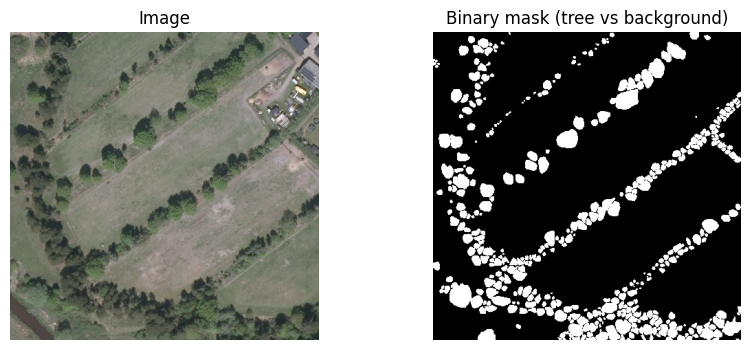

In [15]:
import matplotlib.pyplot as plt

img = image.permute(1, 2, 0).cpu().numpy()
mask = binary_mask.cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Binary mask (tree vs background)")
plt.axis("off")

plt.show()

In [25]:
backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")

# freeze backbone (important au début)
for param in backbone.parameters():
    param.requires_grad = False

Using cache found in /Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main
/Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [14]:
print('\n'*100)